# "Buy when the data beats" — does the Economic Surprise Index work? 🎯
### The desk's favourite macro gauge — high when releases beat forecasts — put to the test, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_nowcast%3F: Busted](https://img.shields.io/badge/Free_nowcast%3F-Busted-8b949e?style=flat-square)

Every trading desk watches Citi's **Economic Surprise Index (CESI)**: a single line that rises when the economy's data keeps **beating** what economists expected, and falls when it **misses**. The folklore is irresistibly simple — *when the data beats, buy stocks; the economy has unpriced good news.*

It sounds like a free nowcast. But the US market drifts **up** most years anyway, and a surprise index runs hottest **coming out of recessions** — exactly when stocks are already staging their biggest recovery rallies. So "beat = up" might just be the recovery drift wearing a clever costume. This notebook pulls the costume off.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test, the Sharpe race and the power control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Citi's CESI is proprietary, and there's **no free history of analyst forecasts**, so we **build a transparent proxy**: from six public FRED series (payrolls, industrial production, retail sales, sentiment, housing, durable orders) we take each month's change minus its **trailing-12-month average** — a labelled stand-in for the consensus — then z-score and average them. It's narrower than CESI and we call it a proxy throughout. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from economic_surprise_index import data, strategy as st

HAVE_REAL = data.have_real()
F = data.build_real() if HAVE_REAL else None
print("real FRED+SPY cache present:", HAVE_REAL,
      "| monthly observations:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-01-31', 'end': '2026-05-31', 'months': 401, 'years': 33.3, 'esi_mean': -0.08, 'esi_std': 1.19, 'esi_frac_pos': 48, 'h1': (1, 191, 0.92, 64, 0.96, 65, -0.1, 0.549), 'h3': (3, 190, 2.87, 72, 2.83, 72, 0.06, 0.473), 'h6': (6, 187, 6.6, 80, 5.79, 76, 0.89, 0.148), 'h12': (12, 184, 13.38, 88, 12.01, 82, 1.0, 0.134), 'timing': [('long / flat', 48, 215, 6.3, 9.5, 0.66, 0.78), ('long / short', 100, 429, 1.0, 15.1, 0.07, 0.78)], 'robust': [(-0.5, 337, 11.7, -0.23, 0.62), (0.0, 184, 13.4, 1.0, 0.134), (0.5, 54, 13.7, 0.78, 0.234)], 'syn': [(0.0, 208, 4.77, 4.38, 0.47, 0.267), (0.04, 208, 12.4, 8.48, 2.22, 0.003)]}


real FRED+SPY cache present: True | monthly observations: 401


## The answer first

| Question | Answer |
|---|---|
| After a 'beat' month, is the market higher a year later? | **Usually — 88% of the time.** That's the seductive headline. |
| Isn't 88% amazing? | **Not really.** *Any* random month is higher a year later **82%** of the time. The beat adds only ~6 points of win-rate — well inside the noise. |
| So is the extra return real? | **Can't tell.** The 12-month bump is ~1.4 points over a normal year, with a Welch **t = 1.00** (you need ≥ 2). At **1–3 months** — where a data release actually moves prices — the excess is essentially **zero**. |
| Could you at least trade it? | **No.** A "hold-when-beating" timing rule earns a **lower Sharpe (0.66) than just buying and holding (0.78)** — sitting out the market on 'miss' months costs more than the surprise returns. |

> The surprise index is a real, useful macro gauge. "Buy when the data beats" is the market's own recovery drift in a costume — small, insignificant, and a loser to trade.

## 1 · The claim

> *"When the economic data keeps coming in **above** what forecasters expected, the economy has positive momentum that isn't priced yet — so buy stocks, and ride the surprise."*

This is the everyday reading of Citi's CESI, charted on every desk against the S&P 500. The picture is intuitive: a run of upside surprises means analysts keep being too pessimistic, the economy is stronger than the price reflects, and equities should catch up. We'll rebuild the surprise index from public data and ask whether "beat" really predicts "up" — or just **coincides** with it.

## 2 · So what?

Two things hide inside "beat = buy," and only one of them matters. (1) *Does the market tend to rise after a beat month?* Sure — but the market tends to rise after **most** months. The question that matters is (2) *does it rise by **more** than usual, reliably enough to bet on?* A high win-rate that merely matches the market's natural up-drift is **not an edge** — it's the base rate in a costume. Worse, a surprise built against a **trailing average** runs high exactly during post-recession recoveries, so it inherits the rally rather than predicting it. And even a real bump is useless if a timing rule built on it **loses to buy-and-hold.**

## 3 · How would we even know?

We rebuild the surprise index on **transparent public data**: six FRED real-activity series, each month's change minus its trailing-12-month average, z-scored and averaged into one **ESI**. A 'beat' month is ESI > 0. Over **33.3 years** (1993-01-31 → 2026-05-31, 401 months) we then:

1. **Mark the beats.** Every month the ESI is positive (data above its own recent pace), acted on one month later — no look-ahead.
2. **Measure the payoff.** For each beat, what did SPY do over the next **1 / 3 / 6 / 12 months** — and how does that compare to a *random* month (the base rate)?
3. **Stress the luck, then try to trade it.** Draw the same number of *random* dates thousands of times to see how often chance matches the beats; then race a "hold-when-beating" rule against buy-and-hold, net of costs.

## 4 · The teardown — let's actually look

**First, here's the surprise index itself.** The ESI rising above zero (data beating its trailing average) and diving below (missing) — overlaid on SPY. Watch how it spikes *after* the 2009 and 2020 bottoms, not before.

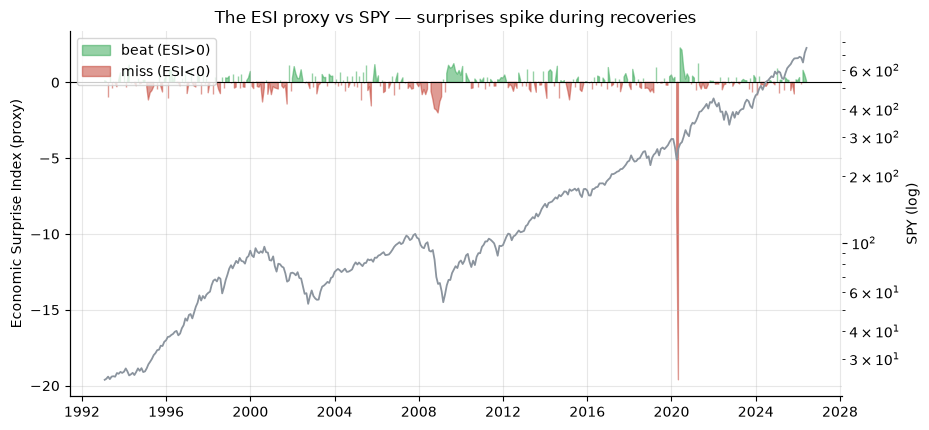

ESI mean -0.08 std 1.19 frac>0 0.48


In [2]:
if HAVE_REAL:
    fig, ax1 = plt.subplots(figsize=(9.4, 4.4))
    ax1.fill_between(F.index, F['esi'], 0, where=(F['esi']>=0), color=GREEN, alpha=.5, label='beat (ESI>0)')
    ax1.fill_between(F.index, F['esi'], 0, where=(F['esi']<0), color=RED, alpha=.5, label='miss (ESI<0)')
    ax1.axhline(0, c='k', lw=.8); ax1.set_ylabel('Economic Surprise Index (proxy)')
    ax2 = ax1.twinx(); ax2.plot(F.index, F['spy'], c=GREY, lw=1.3, label='SPY (right)')
    ax2.set_yscale('log'); ax2.grid(False); ax2.set_ylabel('SPY (log)')
    ax1.set_title('The ESI proxy vs SPY — surprises spike during recoveries')
    ax1.legend(loc='upper left'); plt.tight_layout(); plt.show()
    print('ESI mean', round(F['esi'].mean(),2), 'std', round(F['esi'].std(),2),
          'frac>0', round((F['esi']>0).mean(),2))
else:
    print('no cache — see docs/results.md: ESI mean ', R['esi_mean'], 'std', R['esi_std'])

The index spends about **48%** of months above zero. Crucially, the big green stretches line up with the *aftermath* of crashes — the data beats a depressed trailing average right as the recovery rally is already underway. Now the real question: does a beat predict *extra* return, or just ride the rally?

**The payoff vs a normal month.** For each horizon, the beat month's average forward return and win-rate, next to the *unconditional* base rate — what a random month gives you anyway.

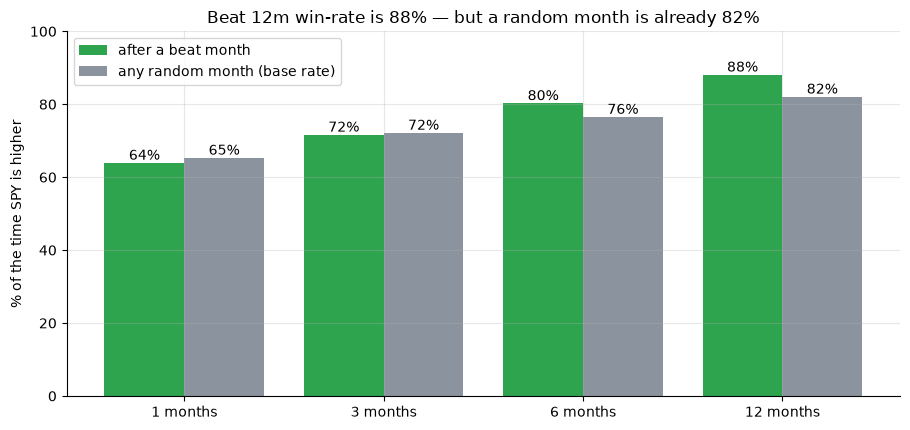

beat 12m win-rate: 88%  base 12m win-rate: 82%


In [3]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    rows = [st.summarize(F, m) for m in hs]
    cwin = [r['cond_win']*100 for r in rows]; bwin = [r['base_win']*100 for r in rows]
else:
    cwin = [R['h1'][3], R['h3'][3], R['h6'][3], R['h12'][3]]
    bwin = [R['h1'][5], R['h3'][5], R['h6'][5], R['h12'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cwin, .4, color=GREEN, label='after a beat month')
ax.bar(x+.2, bwin, .4, color=GREY, label='any random month (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylim(0, 100); ax.set_ylabel('% of the time SPY is higher')
ax.set_title('Beat 12m win-rate is 88% — but a random month is already 82%')
for i,(c,b) in enumerate(zip(cwin,bwin)):
    ax.annotate(f'{c:.0f}%',(i-.2,c),ha='center',va='bottom')
    ax.annotate(f'{b:.0f}%',(i+.2,b),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print('beat 12m win-rate:', f'{cwin[-1]:.0f}%', ' base 12m win-rate:', f'{bwin[-1]:.0f}%')

There's the trick. The **88%** "buy the beat" 12-month win-rate sits just above the **82%** you get on *any* random month — because the US market simply rises most years. At **1 month** the beat's win-rate (**64%**) is actually *below* the base rate (**65%**) — and 1 month is precisely where a data release moves the tape. The headline is mostly the market's own up-drift, not the signal.

**Could a handful of random months look this good?** Here's the honest test: draw the same **184** *random* dates over and over, and see how the beat months' 12-month average return stacks up against pure luck.

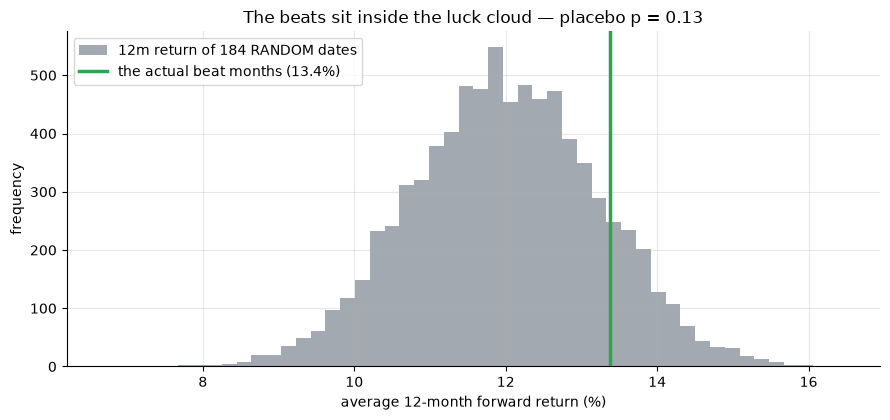

a random 184-date draw beats the signal 13% of the time — far from rare


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(F, 12); obs = pl['cond_mean']; pmean = pl['placebo_mean']; pval = pl['p_value']
    fwd = st.forward_returns(F['spy'], 12).dropna().values; n=len(fwd); k=pl['k']
    rng = np.random.default_rng(387)
    draws = np.array([fwd[rng.integers(0,n,size=k)].mean() for _ in range(8000)])
else:
    obs = R['h12'][2]/100; pmean = R['h12'][4]/100; pval = R['h12'][7]; k = R['h12'][1]
    rng = np.random.default_rng(387); draws = rng.normal(pmean, 0.012, 8000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=50, color=GREY, alpha=.8, label=f'12m return of {k} RANDOM dates')
ax.axvline(obs*100, c=GREEN, lw=2.5, label=f'the actual beat months ({obs*100:.1f}%)')
ax.set_xlabel('average 12-month forward return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The beats sit inside the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random {k}-date draw beats the signal {pval*100:.0f}% of the time — far from rare')

The green line — the actual beat months — falls **inside** the grey cloud of random draws. About **13%** of random 184-date samples do as well or better (~1 time in 7). In plain terms: **the "buy the beat" record is what you'd expect from drawing a few hundred dates in an up-trending market.** Not a nowcast — arithmetic.

## 5 · The verdict

- **Signal — Weak.** Forward returns after a beat are positive and the 12-month win-rate is genuinely high (**88%**) — but it barely beats the **82%** base rate, isn't statistically significant (**t = 1.00**), and is **~zero at 1–3 months** where the news actually moves. Real as a gauge, weak as edge.
- **Tradability — Mirage.** A "hold-when-beating" timing rule earns a **lower Sharpe (0.66) than buy-and-hold (0.78)** — sitting out an up-drifting market on 'miss' months costs more than the surprise returns.
- **"Free nowcast"? — Busted.** A surprise measured against a *trailing average* is mechanically the market's own **post-recession recovery drift** in a costume — priced within minutes of each release, sampled monthly, indistinguishable from luck.

## 6 · Could you actually trade it? — race it against buy-and-hold

Forget significance for a second and just ask the operational question: if you hold SPY only when the data is beating (ESI > 0) and step aside otherwise, do you beat simply owning the market? Here's the Sharpe ratio of each rule next to plain buy-and-hold.

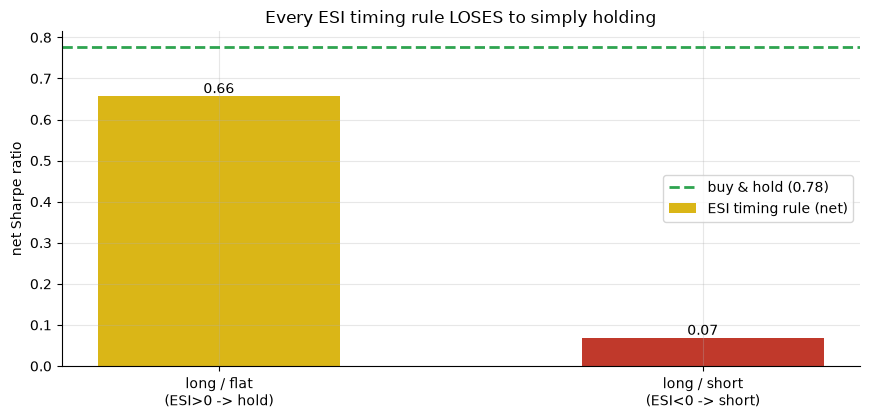

long/flat Sharpe 0.66 vs buy&hold 0.78 -> timing loses


In [5]:
if HAVE_REAL:
    bl = []
    for short in (False, True):
        b = st.timing_backtest(F, cost_bps=10.0, allow_short=short)
        bl.append((b['net']['sharpe'], b['buy_hold']['sharpe']))
    rule_sh = [bl[0][0], bl[1][0]]; bh = bl[0][1]
else:
    rule_sh = [R['timing'][0][5], R['timing'][1][5]]; bh = R['timing'][0][6]
labels = ['long / flat\n(ESI>0 -> hold)', 'long / short\n(ESI<0 -> short)']
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x, rule_sh, .5, color=[AMBER, RED], label='ESI timing rule (net)')
ax.axhline(bh, ls='--', c=GREEN, lw=2, label=f'buy & hold ({bh:.2f})')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('net Sharpe ratio')
ax.set_title('Every ESI timing rule LOSES to simply holding')
for i,s in enumerate(rule_sh): ax.annotate(f'{s:.2f}',(i,s),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print(f'long/flat Sharpe {rule_sh[0]:.2f} vs buy&hold {bh:.2f} -> timing loses')

There it is. The long/flat ESI rule earns a Sharpe of **0.66** against **0.78** for just buying and holding — and that's *before* crediting the interest it would earn while parked in cash, which only flatters the rule. Betting *against* stocks on miss months (long/short) collapses to **0.07** — a direct fight with the equity risk premium. **There is no version of this that beats buy-and-hold.** Costs aren't the problem; being out of an up-drifting market is.

## 7 · Going further 🚪

- **The macro-timing pattern.** Sahm-rule, misery-index, Fed-model and real-rate studies on this bench all rhyme: a *real* macro relationship rarely survives as a **tradable** monthly timing rule once you charge it the opportunity cost of sitting in cash through an up-drifting market.
- **Better consensus.** Swap our trailing-average stand-in for a true survey of analyst forecasts (if you can buy the history) and re-run the detector — the surprise becomes a cleaner forecast error, but the recovery-drift confound and the fast-pricing problem don't go away.
- **Shorter horizons.** Try the announcement-day window itself — that's where a surprise *does* move prices, but it's gone within minutes, long before a monthly rule can act.

*Think "buy the beat" beats the market by more than luck? Build the surprise index, draw the same number of random dates, and show the beats landing **outside** the cloud **and** a timing rule clearing buy-and-hold — then we'll talk.*